# Project 1: Regression Networks for Leakage Detection

Welcome to your first project, *Regression Networks for Leakage Detection*!

This notebook will guide you through the basic steps of many machine learning projects.

You will also learn how to train a fully connected neural network using TensorFlow and how to explain its outputs.

Submissions for Project 1 are due on **November 16** via your group's folder in Stud.IP.

1. Execute the following cell to import the required packages.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from tensorflow import keras

np.random.seed(0)
tf.random.set_seed(0)

### 1.1 Get the data and look at the big picture

2. Read the data `project_1_data.csv` into a Pandas DataFrame `df`.

In [3]:
# Read the data into Pandas dataframe
df = pd.read_csv("project_1_data.csv")

3.  Use the `pandas.DataFrame.head` method to display the first ten rows of `df`.

In [4]:
# Display the first ten rows of df
df.head(10)

,mfc1,mfc2,mfc3,mfc4,x1,y1,split
0,0.032288,0.042917,0.138325,0.049690,0.776000,0.091500,train
1,0.072701,0.013376,0.000000,0.014704,0.020950,0.870975,train
2,0.008946,0.013876,0.061170,0.015882,0.857550,0.037675,train
3,0.077295,0.064222,0.053470,0.077156,0.384475,0.515575,train
4,0.028608,0.019787,0.012829,0.041254,0.102900,0.423675,train
5,0.049257,0.044471,0.052168,0.111638,0.311900,0.219125,train
6,0.056709,0.022876,0.000000,0.018870,0.239025,0.997650,train
7,0.044065,0.054737,0.084059,0.063467,0.644525,0.280200,train
8,0.070663,0.507589,0.060942,0.056632,0.886750,0.926600,train
9,0.388159,0.123097,0.076123,0.106485,0.231525,0.941250,train


4.  Use the `pandas.DataFrame.dtypes` attribute to display the data type of each column.

In [5]:
# Display the data type of each column
df.dtypes

,0
mfc1,float64
mfc2,float64
mfc3,float64
mfc4,float64
x1,float64
y1,float64
split,object


We require all numerical data to be in ```float32``` format.

5. Convert all respective columns of data type ```float64``` to ```float32```.

In [6]:
# Convert all float64 columns to float32
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')

6. Repeat step 4. to check the datatypes again.

In [7]:
# Check the data types again to confirm conversion
df.dtypes

,0
mfc1,float32
mfc2,float32
mfc3,float32
mfc4,float32
x1,float32
y1,float32
split,object


The ```split``` column indicates whether a sample belongs to the training or testing dataset.

7. Use the ```pandas.DataFrame.value_counts``` method to determine the number of samples in each set.

In [8]:
# Count how many samples belong to each split (train/test)
df['split'].value_counts()

,count
split,
train,285
test,32


8. Use the `pandas.DataFrame.describe` method to display some descriptive statistics of the data.

In [9]:
# Display descriptive statistics of the data
df.describe()

,mfc1,mfc2,mfc3,mfc4,x1,y1
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000
mean,0.080808,0.087735,0.086143,0.091634,0.508412,0.505459
std,0.082998,0.097347,0.092340,0.090783,0.303643,0.299975
min,0.000000,0.000000,0.000000,0.000000,0.003050,0.009175
25%,0.027689,0.027054,0.021811,0.034433,0.231525,0.237175
50%,0.052562,0.052603,0.049390,0.060093,0.499250,0.500925
75%,0.113377,0.115951,0.115201,0.112480,0.782450,0.790400
max,0.518818,0.632674,0.648653,0.672211,0.997550,0.998325


9. Use `seaborn.scatterplot` to visualize the output training data, namely the coordinates `(x1, y1)` for each sample. Complete the code below.

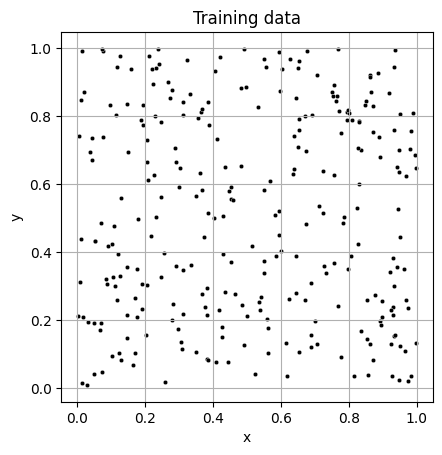

In [10]:
# None values replaced

train_df = df[df['split'] == 'train']  # filter only training samples

plt.figure()
sns.scatterplot(data=train_df, x='x1', y='y1', color='black', s=10.0)
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training data')
plt.show()

10. Now repeat the same for the test data.

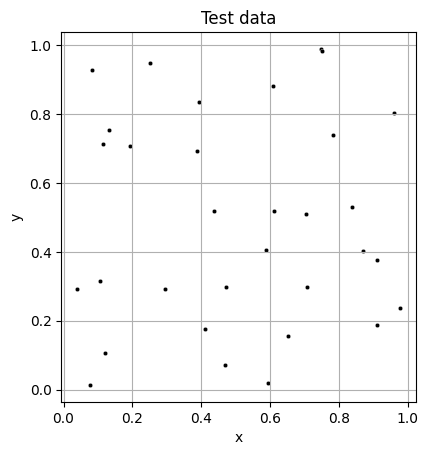

In [11]:
# Scatter plot for test data
plt.figure()
sns.scatterplot(data=df[df['split'] == 'test'], x='x1', y='y1', color='black', s=10.0)
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Test data')
plt.show()

11. Run the following code.

As a result, you will be able to easily query the data frame for input and output data and training and test data.

In [12]:
cols_mfc = ['mfc1', 'mfc2', 'mfc3', 'mfc4']
cols_target = ['x1', 'y1']
rows_train = df['split'] == 'train'
rows_test = df['split'] == 'test'

12. Now, use the ```pandas.DataFrame.hist``` method with ```bins=50``` to display histograms of the ```mfc``` columns.

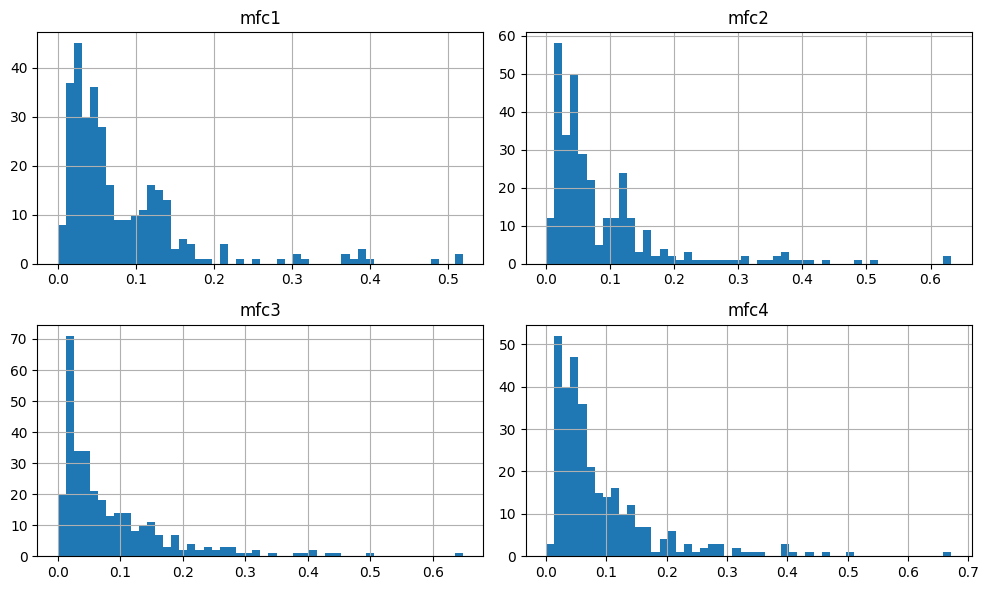

In [13]:
# Display histograms of the mfc columns
df[cols_mfc].hist(bins=50, figsize=(10, 6))
plt.tight_layout()
plt.show()

### 1.2 Prepare the data

Scaling the input data can speed up the convergence of the optimization procedure required to fit the parameters of a machine learning model. It can also lead to a better solution in terms of data fit. There are numerous scaling approaches, and the most effective approach depends on the data. Here, we will use two methods: min-max scaling, which linearly transforms the data into a specified range, and min-max scaling with  preceding log-transform and winsorizing steps. The log-transform helps distribute the values more evenly within the range ```[0, 1]```. Winsorizing can be thought of as clipping outliers below or above a specified quantile threshold.

13. Complete the following code to perform min-max scaling.

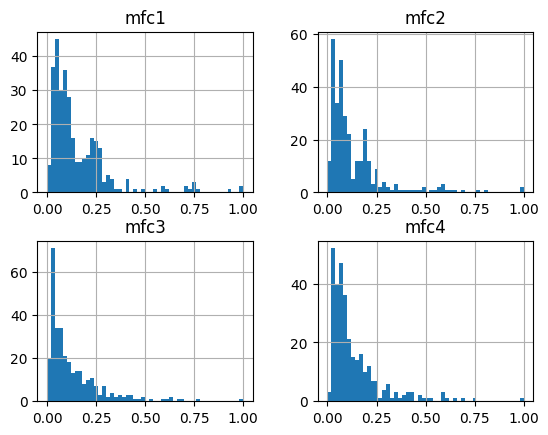

,mfc1,mfc2,mfc3,mfc4
count,317.000000,317.000000,317.000000,317.000000
mean,0.155754,0.138673,0.132803,0.136318
std,0.159974,0.153866,0.142357,0.135052
min,0.000000,0.000000,0.000000,0.000000
25%,0.053370,0.042761,0.033626,0.051224
50%,0.101311,0.083144,0.076143,0.089396
75%,0.218530,0.183272,0.177600,0.167329
max,1.000000,1.000000,1.000000,1.000000


In [14]:
# None values replaced
min_target = 0.0
max_target = 1.0
df_minmax = df.copy()
min_data = df.loc[rows_train, cols_mfc].min()
max_data = df.loc[rows_train, cols_mfc].max()
df_minmax[cols_mfc] = (df_minmax[cols_mfc] - min_data) * (max_target - min_target) / (max_data - min_data) + min_target
df_minmax[cols_mfc].hist(bins=50)
plt.show()
df_minmax[cols_mfc].describe()

**Checkpoint:** If your implementation of min-max scaling is correct, each transformed column should afterwards have a ```min``` value of zero and a ```max``` value of one.

14. Complete the following code to perform min-max scaling with a preceding winsorizing step.

What differences can you observe?

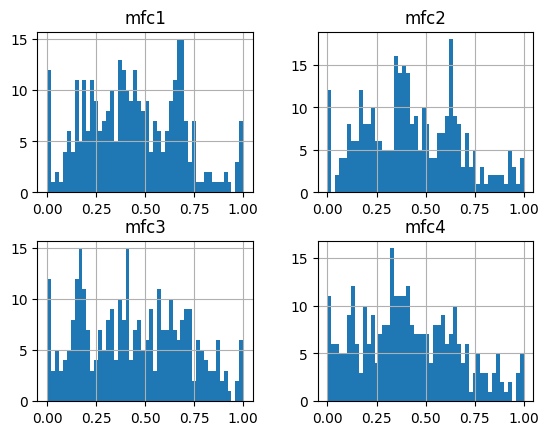

,mfc1,mfc2,mfc3,mfc4
count,317.000000,317.000000,317.000000,317.000000
mean,0.441889,0.433619,0.444392,0.414107
std,0.237873,0.239045,0.259840,0.248298
min,0.000000,0.000000,0.000000,0.000000
25%,0.249543,0.236965,0.201517,0.222719
50%,0.427864,0.412454,0.420259,0.393052
75%,0.641734,0.621053,0.646925,0.584794
max,1.000000,1.000000,1.000000,1.000000


In [15]:
# None values replaced
df_wins = df.copy()
df_wins[cols_mfc] = np.log(df_wins[cols_mfc] + 1e-10)
lower = df_wins.loc[rows_train, cols_mfc].quantile(0.03)
upper = df_wins.loc[rows_train, cols_mfc].quantile(0.99)
df_wins[cols_mfc] = df_wins[cols_mfc].clip(lower=lower, upper=upper, axis=1)
min_data = df_wins.loc[rows_train, cols_mfc].min()
max_data = df_wins.loc[rows_train, cols_mfc].max()
df_wins[cols_mfc] = (df_wins[cols_mfc] - min_data) * (max_target - min_target) / (max_data - min_data) + min_target
df_wins[cols_mfc].hist(bins=50)
plt.show()
df_wins = df_wins.astype({col: "float32" for col in df_wins.select_dtypes(include=["float64"]).columns})
df_wins[cols_mfc].describe()

**Checkpoint:** If your implementation of min-max scaling with preceding log-transform and winsorizing is correct, the ```min``` and ```max``` of each column should still be zero or one, respectively. Moreover, you should observe that the mean of each column is now between ```0.4``` and ```0.45``` (i.e., closer to the middle of the range ```[0, 1]```), and that the standard deviation has increased.

15. Execute the following code to subdivide the training data into training and validation sets.

The validation data can be used, for example, to compare the performance of different candidate machine learning models and select the best one. In contrast, test data is only used at the end to evaluate the final model's performance.

Afterwards, we will train our first model on the min-max scaled data without preceding winsorizing.

In [16]:
X_train, X_val, Y_train, Y_val = train_test_split(df_minmax.loc[rows_train, cols_mfc], df.loc[rows_train, cols_target], test_size=0.1, random_state=0)
X_test, Y_test = df_minmax.loc[rows_test, cols_mfc], df.loc[rows_test, cols_target]

rows_train = X_train.index
rows_val = X_val.index
df.loc[rows_val, 'split'] = 'val'

### 1.2 Train a fully connected neural network

Gradient descent methods are commonly used to train neural networks by fitting their parameters to training data. For gradient steps, one can use a constant learning rate, i.e., step size, or a learning rate schedule to allow for smoother convergence. Here, we use the latter.

16. Complete the following code to set up and compare linear and exponential decay learning rate schedules.

The ```decay_steps``` parameter of both schedules should be set to the total number of gradient steps to be performed during training. To get the number of gradient steps per epoch, it helps to figure the number of batches that results when the training data is subdivided into batches of batch size ```batch_size```.

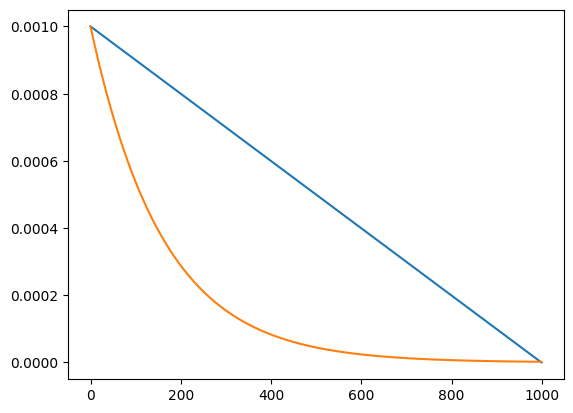

In [17]:
# None values replaced
epochs = 1000
batch_size = 8
initial_learning_rate = 1e-3

decay_steps = epochs * (X_train.shape[0] // batch_size)

lr_scheduler_polynomial = keras.optimizers.schedules.PolynomialDecay(initial_learning_rate=initial_learning_rate, decay_steps=decay_steps, end_learning_rate=0, power=1)
lr_scheduler_exponential = keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=initial_learning_rate, decay_steps=decay_steps, decay_rate=0.002)
plt.plot([lr_scheduler_polynomial(i) for i in np.linspace(0, epochs * (X_train.shape[0] // batch_size), epochs)])
plt.plot([lr_scheduler_exponential(i) for i in np.linspace(0, epochs * (X_train.shape[0] // batch_size), epochs)])
plt.show()

17. Complete the following code to define a neural network using the ```tf.keras.Sequential``` API. Then, use the ```tf.keras.Model.fit``` method to train a neural network.

The ```width``` parameter controls the number of neurons, or units, in each hidden layer. The number of units in the input and output layer is determined by the data. The ```depth``` parameter controls the number of hidden layers. Therefore, the network will have ```depth + 1``` layers, including the output layer and excluding the input layer, which has no parameters.

In [18]:
# None values replaced
depth = 10
width = 2048

model = keras.models.Sequential([keras.layers.Dense(width, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-5)) for _ in range(depth)])
model.add(keras.layers.Dense(2))

model.compile(loss='mse', optimizer=keras.optimizers.Adam(lr_scheduler_exponential))

history = model.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, Y_val))

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 2.7273 - val_loss: 0.2059
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1901 - val_loss: 0.1277
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1461 - val_loss: 0.1149
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1332 - val_loss: 0.1011
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1188 - val_loss: 0.1031
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1158 - val_loss: 0.0970
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1125 - val_loss: 0.0977
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1115 - val_loss: 0.0945
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1090 - val_loss: 0.0920
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1055 - val_loss: 0.0916
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1029 - val_loss: 0.0957
Epoch 12/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 

**Checkpoint:** If you did not change the preset parameters and your implementation is correct, then your loss value should be below ```0.002```.

18. Run the following code to visualize learning progress on the training and test data.

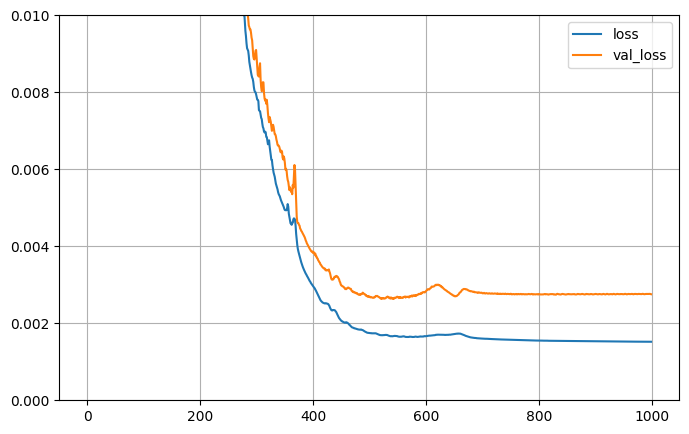

In [19]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.ylim([0, 0.01])
plt.grid(True)
plt.show()

19. Repeat the same training procedure to train another model ```model_wins```, this time using the winsorized data instead. Complete the following code.

Which model wins the comparison in terms of validation loss?

In [20]:
# None values replaced
X_train_wins, Y_train_wins = df_wins.loc[rows_train, cols_mfc], df.loc[rows_train, cols_target]
X_val_wins,   Y_val_wins   = df_wins.loc[rows_val,   cols_mfc], df.loc[rows_val,   cols_target]
X_test_wins,  Y_test_wins  = df_wins.loc[rows_test,  cols_mfc], df.loc[rows_test,  cols_target]

# Create and train the winsorized model

depth = 10
width = 2048

model_wins = keras.models.Sequential([keras.layers.Dense(width, activation='relu',kernel_regularizer=keras.regularizers.l2(1e-5)) for _ in range(depth)])
model_wins.add(keras.layers.Dense(2))
model_wins.compile(loss='mse', optimizer=keras.optimizers.Adam(lr_scheduler_exponential))
history_wins = model_wins.fit(X_train_wins, Y_train_wins,batch_size=batch_size,epochs=epochs,validation_data=(X_val_wins, Y_val_wins))

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.3808 - val_loss: 0.1828
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1831 - val_loss: 0.1178
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1387 - val_loss: 0.0999
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1160 - val_loss: 0.0869
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1065 - val_loss: 0.0820
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0973 - val_loss: 0.0828
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1095 - val_loss: 0.0815
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0967 - val_loss: 0.0720
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0810 - val_loss: 0.0736
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0932 - val_loss: 0.0705
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0812 - val_loss: 0.0750
Epoch 12/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 

### 1.5 Visualize model outputs

Now, visualize and evaluate the outputs of your winning model in terms of the test data. Remember that the test data should not be used to compare different models. Its sole purpose is to evaluate the performance of the final selected model. In practice, we usually consider more than two models.

20. Complete the following cells.

In [21]:
# None values replaced
x1_y1_pred = model_wins.predict(df_wins[cols_mfc])

df_pred = df.copy()
df_pred['x1'] = x1_y1_pred[:, 0]
df_pred['y1'] = x1_y1_pred[:, 1]
df_pred['type'] = 'pred'
df['type'] = 'true'
df_true_pred = pd.concat([df, df_pred], axis=0)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


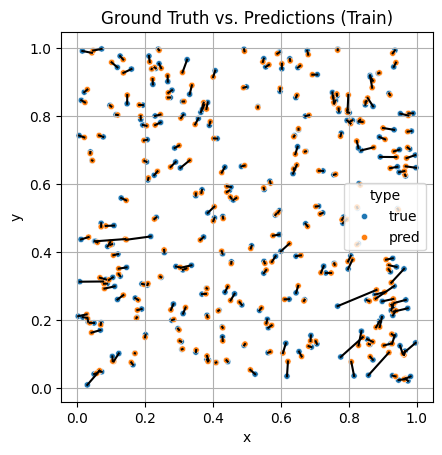

In [22]:
# visualize predictions on training data
x1_y1_true_train = df_true_pred.loc[(df_true_pred['type'] == 'true') & (df_true_pred['split'] == 'train'), cols_target].values
x1_y1_pred_train = df_true_pred.loc[(df_true_pred['type'] == 'pred') & (df_true_pred['split'] == 'train'), cols_target].values
plt.figure()
sns.scatterplot(data=df_true_pred[(df_true_pred['split'] == 'train')], x='x1', y='y1', hue='type', s=20.0)
plt.plot((x1_y1_true_train[:, 0], x1_y1_pred_train[:, 0]), (x1_y1_true_train[:, 1], x1_y1_pred_train[:, 1]), 'k')
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ground Truth vs. Predictions (Train)')
plt.show()

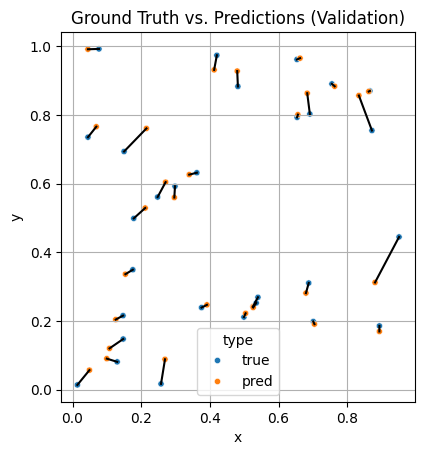

In [23]:
# visualize predictions on validation data
x1_y1_true_val = df_true_pred.loc[(df_true_pred['type'] == 'true') & (df_true_pred['split'] == 'val'), cols_target].values
x1_y1_pred_val = df_true_pred.loc[(df_true_pred['type'] == 'pred') & (df_true_pred['split'] == 'val'), cols_target].values
plt.figure()
sns.scatterplot(data=df_true_pred[(df_true_pred['split'] == 'val')], x='x1', y='y1', hue='type', s=20.0)
plt.plot((x1_y1_true_val[:, 0], x1_y1_pred_val[:, 0]), (x1_y1_true_val[:, 1], x1_y1_pred_val[:, 1]),'k')
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ground Truth vs. Predictions (Validation)')
plt.show()

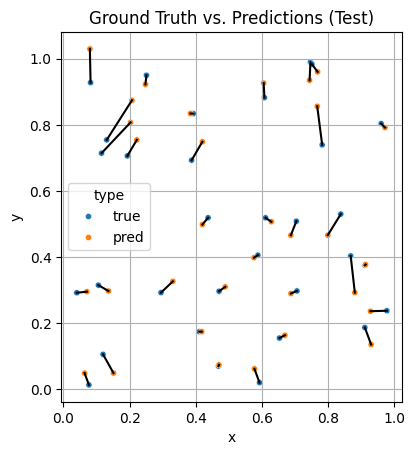

In [24]:
# visualize predictions on test data

x1_y1_true_test = df_true_pred.loc[(df_true_pred['type'] == 'true') & (df_true_pred['split'] == 'test'), cols_target].values
x1_y1_pred_test = df_true_pred.loc[(df_true_pred['type'] == 'pred') & (df_true_pred['split'] == 'test'),cols_target].values
plt.figure()
sns.scatterplot(data=df_true_pred[(df_true_pred['split'] == 'test')], x='x1', y='y1', hue='type', s=20.0)
plt.plot((x1_y1_true_test[:, 0], x1_y1_pred_test[:, 0]), (x1_y1_true_test[:, 1], x1_y1_pred_test[:, 1]),'k')
plt.grid(True)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ground Truth vs. Predictions (Test)')
plt.show()


In [25]:
model_wins.evaluate(X_test_wins, Y_test_wins)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 0.0025


0.0025418875738978386

### 1.4 Implement a custom training loop

One practical advantage of TensorFlow is that it handles the technical aspects of training a neural network, so we don't have to worry about them. The tf.keras.Model.fit method manages all the necessary internal processes. However, the fit method is a black box. In many cases, such as when things do not work as expected or when we want to customize our training procedure, it is helpful to understand what is happening inside the black box.

The class ```tf.data.Dataset``` is used to handle the data when the fit method is called. In the following you will first create such a TensorFlow dataset and then use


- ```tf.data.Dataset.shuffle``` to shuffle the items of the dataset randomly and
- ```tf.data.Dataset.batch``` to group items of a dataset in batches of a certain size .

The usage of ```tf.data.Dataset``` is particularly efficient for very large datasets, because only a fraction of the entire dataset is kept in the working memory at each time during training. Required data are loaded sequentially from disk into working memory and preprocessed. This prevents delays during training that could be caused by data loading and preprocessing. Further information can be found under https://www.tensorflow.org/api_docs/python/tf/data/Dataset.

10. Create a TensorFlow dataset ```train_dataset``` for the training data using the ```tf.data.Dataset.from_tensor_slices``` method, then apply ```tf.data.Dataset.shuffle``` (with arguments ```buffer_size=X_train.shape[0]``` and ```reshuflle_each_iteration=True```) and ```tf.data.Dataset.batch``` (with argument ```batch_size```) to ```train_ds```. Use the data (with or without winsorizing) that won the above comparison.

In [26]:
# None values replaced
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_wins, Y_train_wins))
train_dataset = train_dataset.shuffle(buffer_size=X_train_wins.shape[0], reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size)

**Checkpoint**: If you initialized and transformed ```train_dataset``` correctly, the following code should first display an input-output tuple ```(<tf.Tensor: shape=(8, 4) ..., <tf.Tensor: shape=(8, 4) ...)```, and then a dataset length of ```32```.

In [27]:
print(*[item for item in train_dataset.take(1)])
print()
print(len(train_dataset))

(<tf.Tensor: shape=(8, 4), dtype=float32, numpy=
array([[0.08330034, 0.11100686, 0.02037522, 0.4291154 ],
       [0.        , 0.        , 0.        , 0.5145501 ],
       [0.54545295, 0.6052302 , 0.97443897, 0.5836742 ],
       [0.51354694, 0.5651978 , 1.        , 0.56451136],
       [0.66553044, 0.7330992 , 0.8663464 , 0.6806902 ],
       [0.47480574, 0.40691048, 0.5128806 , 0.584794  ],
       [0.32012   , 0.7047081 , 0.3606872 , 0.24457549],
       [0.21335611, 0.14496882, 0.18184319, 0.39871052]], dtype=float32)>, <tf.Tensor: shape=(8, 2), dtype=float32, numpy=
array([[0.164375, 0.068525],
       [0.0723  , 0.0478  ],
       [0.89045 , 0.1972  ],
       [0.862025, 0.1286  ],
       [0.75695 , 0.3667  ],
       [0.38115 , 0.29395 ],
       [0.95145 , 0.80775 ],
       [0.1711  , 0.26485 ]], dtype=float32)>)

32


21. Understand and complete the following code to implement and execute a custom training loop.

Create a ```tf.keras.Sequential``` model named ```model_custom``` that has the same architecture as the ```model``` above. In a custom training loop the model does not need to be compiled. The ```tf.keras.Model.compile``` method tells TensorFlow which loss function, metrics and optimizer to use. This will also be done manually here.

The ```train_step``` function computes the gradient of the loss function (including regularization) with respect to the model parameters for a single batch. TensorFlow's automatic differentiation capabilities are used for this purpose via ```tf.GradientTape```. Then, the model's parameters are updated with the computed gradient.

See what happens if you leave out the ```@tf.function``` decorator. Why is that?

In [28]:
# None values replaced
model_custom = keras.models.Sequential([keras.layers.Dense(width, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-5)) for _ in range(depth)])
model_custom.add(keras.layers.Dense(2))

loss_function = keras.losses.MeanSquaredError()
loss_metric = keras.metrics.Mean(name='loss')
optimizer = keras.optimizers.Adam(lr_scheduler_exponential)

def print_status_bar(iteration, val_loss, start_time):
    elapsed = time.time() - start_time
    sec_per_step = elapsed / iteration * 1000
    time_str = f"{sec_per_step:.2f}ms/step"
    loss_str = ' - loss: {:.7f}'.format(loss_metric.result())
    val_loss_str = '' if iteration < len(train_dataset) else ' - val_loss: {:.7f}'.format(val_loss)
    end_str = '' if iteration < len(train_dataset) else '\n'

    print('\r{}/{} - '.format(iteration, len(train_dataset)) + time_str + loss_str + val_loss_str, end=end_str)

@tf.function
def train_step(X_batch, Y_batch):
    with tf.GradientTape() as tape:
        Y_pred = model_custom(X_batch)
        loss = loss_function(Y_batch, Y_pred)
        if model_custom.losses:
            loss += tf.add_n(model_custom.losses)
    grad = tape.gradient(loss, model_custom.trainable_variables)
    optimizer.apply_gradients(zip(grad, model_custom.trainable_variables))
    loss_metric.update_state(loss)

history = {'loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f'Epoch {epoch}/{epochs}')
    loss_metric.reset_state()
    start_time = time.time()
    for step, (X_batch, Y_batch) in enumerate(train_dataset):
        train_step(X_batch, Y_batch)
        if step + 1 < len(train_dataset):
            print_status_bar(step + 1, 0, start_time)
        else:
            Y_pred_val = model_custom(X_val_wins.values)
            val_loss = loss_function(Y_val_wins.values, Y_pred_val)
            if model_custom.losses:
                val_loss += tf.add_n(model_custom.losses)
            history['loss'].append(loss_metric.result().numpy())
            history['val_loss'].append(val_loss.numpy())
            print_status_bar(len(train_dataset), val_loss, start_time)

Epoch 1/1000
32/32 - 141.70ms/step - loss: 13.8105240 - val_loss: 0.2169286
Epoch 2/1000
32/32 - 33.08ms/step - loss: 0.1636783 - val_loss: 0.1265768
Epoch 3/1000
32/32 - 33.73ms/step - loss: 0.1189010 - val_loss: 0.0981754
Epoch 4/1000
32/32 - 32.40ms/step - loss: 0.1082515 - val_loss: 0.0928410
Epoch 5/1000
32/32 - 32.03ms/step - loss: 0.1023913 - val_loss: 0.0883880
Epoch 6/1000
32/32 - 32.04ms/step - loss: 0.0989158 - val_loss: 0.0854699
Epoch 7/1000
32/32 - 32.05ms/step - loss: 0.0968386 - val_loss: 0.0879052
Epoch 8/1000
32/32 - 31.95ms/step - loss: 0.0991341 - val_loss: 0.0922765
Epoch 9/1000
32/32 - 31.98ms/step - loss: 0.0980941 - val_loss: 0.0836600
Epoch 10/1000
32/32 - 32.06ms/step - loss: 0.0933681 - val_loss: 0.0823541
Epoch 11/1000
32/32 - 32.04ms/step - loss: 0.0933427 - val_loss: 0.0807366
Epoch 12/1000
32/32 - 32.01ms/step - loss: 0.0920703 - val_loss: 0.0826727
Epoch 13/1000
32/32 - 32.05ms/step - loss: 0.0921858 - val_loss: 0.0799831
Epoch 14/1000
32/32 - 32.87ms/st

### 1.6 Implement gradient backpropagation

Now, we will customize our training loop further. Specifically, we will replace automatic differentiation with manually computed gradients.

The backpropagation algorithm for fully connected neural networks operates as follows (refer to the neural networks course script provided Stud.IP for a better understanding of why it works like this):

<br>

$W^{[l]}\in \mathbb{R}^{n_{l-1}\times n_{l}}\qquad b^{[l]} \in \mathbb{R}^{n_{l}}\qquad A^{[0]} = X \in \mathbb{R}^{s\times n0}\qquad Y \in \mathbb{R}^{s\times n_{L}}$

<br>

Perform forward pass:

```for l=1,...,L do```

$Z^{[l]} = A^{[l-1]}W^{[l]} + b^{[l]}$

$A^{[l]} = \text{ReLU}(Z^{[l]})$

```end```

<br>

Perform backward pass:

$\Delta^{[L]} = A^{[L]} - Y$

$\nabla_{W^{[L]}} = \frac1s (A^{[L-1]})^{T} \Delta^{[L]}$

$\nabla_{b^{[L]}} = \frac1s \mathbb{1}^T \Delta^{[L]}$

```for l=L-1,...,1 do```

$\Delta^{[l]} = \text{ReLU}'(Z^{[l]}) \odot [\Delta^{[l+1]} (W^{[l+1]})^T]$

$\nabla_{W^{[l]}} = \frac1s (A^{[l-1]})^{T} \Delta^{[l]}$

$\nabla_{b^{[l]}} = \frac1s \mathbb{1}^T \Delta^{[l]}$

```end```

22. Run the following cell to generate a random data batch for comparing your manual gradient computation with TensorFlow's automatic differentiation.

In [29]:
X_rnd = np.random.uniform(size=X_val.values.shape).astype('float32')
Y_rnd = np.random.uniform(size=Y_val.values.shape).astype('float32')

with tf.GradientTape() as tape:
    Y_pred = model_custom(X_rnd)
    loss = loss_function(Y_rnd, Y_pred)
grad_tf = tape.gradient(loss, model_custom.trainable_variables)

23. Complete the following code.

Be careful with indexing. For example, note that ```A``` will have one more item than ```Z```, so ```A[i]``` and ```Z[i]``` will not refer to the same layer of the network.

In [30]:
# None values replaced
relu_prime = lambda z: tf.cast(z > 0, z.dtype)

def my_grad(model, X_batch, Y_batch):

    grad = []

    s = tf.cast(tf.shape(X_batch)[0], tf.float32)

    # Forward pass
    Z = []
    A = [X_batch]

    for l, layer in enumerate(model.layers):
        W = layer.kernel
        b = layer.bias
        Z_l = tf.matmul(A[-1], W) + b
        Z.append(Z_l)
        if l < len(model.layers) - 1:
            A_l = tf.nn.relu(Z_l)
        else:
            A_l = Z_l   # linear output

        A.append(A_l)

    # Backward: last layer
    Delta = [A[-1] - Y_batch]

    W_L = tf.matmul(tf.transpose(A[-2]), Delta[0]) / s
    b_L = tf.reduce_sum(Delta[0], axis=0) / s
    grad = [W_L, b_L]

    # Backprop through hidden layers
    for l in range(len(model.layers) - 2, -1, -1):
        W_next = model.layers[l + 1].kernel
        Delta_l = relu_prime(Z[l]) * tf.matmul(Delta[0], tf.transpose(W_next))

        Delta.insert(0, Delta_l)

        grad_W = tf.matmul(tf.transpose(A[l]), Delta_l) / s
        grad_b = tf.reduce_sum(Delta_l, axis=0) / s

        grad.insert(0, grad_W)
        grad.insert(1, grad_b)

    return grad, A

grad_custom, _ = my_grad(model_custom, X_rnd, Y_rnd)

24. Run the following cell to compute the mean squared error between automatic differentiation and manual gradient.

In [31]:
tf.add_n([tf.reduce_mean((g1 - g2) ** 2) for g1, g2 in zip(grad_tf, grad_custom)]).numpy()

np.float32(1.1234901e-16)

**Checkpoint**: If your implementation isn correct, the error should be well below ```1e-10```.

25. Train a neural network using your manual gradient computation.

Create a ```tf.keras.Sequential``` model named ```model_custom_grad``` that has the same architecture as the ```model``` above.

Modify the ```train_step``` model so that your custom gradient computation is used instead of automatic differentiation.

In [32]:
# None values replaced
l2_weight = 1e-5
model_custom_grad = keras.models.Sequential([keras.layers.Dense(width, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_weight)) for _ in range(depth)])
model_custom_grad.add(keras.layers.Dense(2))
model_custom_grad(X_val.values)

loss_function = keras.losses.MeanSquaredError()
loss_metric = keras.metrics.Mean(name='loss')
optimizer = keras.optimizers.Adam(lr_scheduler_exponential)

def print_status_bar(iteration, val_loss, start_time):
    elapsed = time.time() - start_time
    sec_per_step = elapsed / iteration * 1000
    time_str = f"{sec_per_step:.2f}ms/step"
    loss_str = ' - loss: {:.7f}'.format(loss_metric.result())
    val_loss_str = '' if iteration < len(train_dataset) else ' - val_loss: {:.7f}'.format(val_loss)
    end_str = '' if iteration < len(train_dataset) else '\n'

    print('\r{}/{} - '.format(iteration, len(train_dataset)) + time_str + loss_str + val_loss_str, end=end_str)

@tf.function
def train_step(X_batch, Y_batch):

    grad, A = my_grad(model_custom_grad, X_batch, Y_batch)

    # L2 weight penalty added ONLY to weights (0,2,4,...)
    for i in range(0, 2 * (len(model_custom_grad.layers) - 1), 2):
        grad[i] += 2 * l2_weight * model_custom_grad.trainable_variables[i]

    optimizer.apply_gradients(zip(grad, model_custom_grad.trainable_variables))

    loss = loss_function(Y_batch, A[-1])
    if model_custom_grad.losses:
        loss += tf.add_n(model_custom_grad.losses)
    loss_metric.update_state(loss)

# TRAINING LOOP
history = {'loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}/{epochs}")
    loss_metric.reset_state()
    start_time = time.time()
    for step, (X_batch, Y_batch) in enumerate(train_dataset):
        train_step(X_batch, Y_batch)
        if step + 1 < len(train_dataset):
            print_status_bar(step + 1, 0, start_time)
        else:
            Y_pred_val = model_custom_grad(X_val_wins.values)
            val_loss = loss_function(Y_val_wins.values, Y_pred_val)
            if model_custom_grad.losses:
              val_loss += tf.add_n(model_custom_grad.losses)
            history['loss'].append(loss_metric.result().numpy())
            history['val_loss'].append(val_loss.numpy())
            print_status_bar(len(train_dataset), val_loss, start_time)

Epoch 1/1000
32/32 - 139.40ms/step - loss: 0.2330420 - val_loss: 0.0917275
Epoch 2/1000
32/32 - 28.99ms/step - loss: 0.0872814 - val_loss: 0.0554825
Epoch 3/1000
32/32 - 28.94ms/step - loss: 0.0581446 - val_loss: 0.0420368
Epoch 4/1000
32/32 - 29.04ms/step - loss: 0.0594224 - val_loss: 0.0508918
Epoch 5/1000
32/32 - 29.17ms/step - loss: 0.0525706 - val_loss: 0.0405557
Epoch 6/1000
32/32 - 29.00ms/step - loss: 0.0485686 - val_loss: 0.0411625
Epoch 7/1000
32/32 - 29.14ms/step - loss: 0.0465815 - val_loss: 0.0350643
Epoch 8/1000
32/32 - 29.10ms/step - loss: 0.0402824 - val_loss: 0.0354533
Epoch 9/1000
32/32 - 29.00ms/step - loss: 0.0431180 - val_loss: 0.0512520
Epoch 10/1000
32/32 - 29.38ms/step - loss: 0.0554130 - val_loss: 0.0581339
Epoch 11/1000
32/32 - 29.25ms/step - loss: 0.0509843 - val_loss: 0.0480343
Epoch 12/1000
32/32 - 30.17ms/step - loss: 0.0497970 - val_loss: 0.0618021
Epoch 13/1000
32/32 - 30.16ms/step - loss: 0.0508523 - val_loss: 0.0495221
Epoch 14/1000
32/32 - 29.71ms/ste

**Checkpoint**: The training loop with the custom gradient computation should produce a loss that is roughly the same as the ones above.

### 1.7 Explain model predictions

Now, we will implement a method to explain the relation between model input and prediction: *Layer-Wise Relevance Propagation* (LRP) computes one so-called relevance score per input, which can be considered the contribution of that input to the model prediction. To that end, relevance scores for all neurons in the network are successively generated via backpropagation from the output layer to the input layer.

<br>

Relevance scores for the output layer are initially defined using the model normalized model output

<br>

$\displaystyle r^{[L]} = \frac{a^{[L]}}{a^{[L]}_1 + \dots + a^{[L]}_{n_L}}$

<br>

Afterwards, relevance scores $r^{[L-1]}, r^{[L-2]}, \dots, r^{[1]}, r^{[0]}$ (in exactly this order) are computed for all other layers as follows:

<br>

$\displaystyle r^{[\ell-1]} := \alpha \ a^{[\ell - 1]} \ \odot \left( \frac{r^{[l]}}{a^{[\ell - 1]}W^{[\ell]+}} \ (W^{[\ell]+})^\top \right) \ + \ \beta \ a^{[\ell - 1]} \ \odot \left( \frac{r^{[l]}}{a^{[\ell - 1]}W^{[\ell]-}} \ (W^{[\ell]-})^\top \right)$

<br>

$W^{[\ell]+} := \max(W^{[\ell]}, 0)$ denotes the positive part of $W^{[\ell]}$.

$W^{[\ell]-} := \min(W^{[\ell]}, 0)$ denotes the negative part of $W^{[\ell]}$.

$\odot$ denotes componentwise multiplication.

$\displaystyle \frac{\cdot}{\cdot}$ in this case also denotes componentwise division.

<br>

The scalar values $\alpha, \beta \geq 0$ are chosen such that $\alpha - \beta = 1$. Therewith, it can be shown that

<br>

$\sum_j r^{[L]}_j = \sum_j r^{[L-1]}_j = \sum_j r^{[L-2]}_j = \dots = \sum_j r^{[1]}_j = \sum_j r^{[0]}_j$

<br>

holds. Therefore, LRP has a so-called *relevance conservation property*.

<br>

The above formulas are kept as brief as possible. However, they have a concrete interpretation: Each neuron in a layer contributes positively or negatively to all neuron activations in successive layers. The relevance score of a neuron can be considered a proportionate sum of these contributions, and that is exactly reflected in the above formulas. For a more comprehensive text on LRP, see the material in the Stud.IP courseware.

<br>

26. Complete the following function at the positions indicated by ```None``` such that it fits exactly with the above LRP formula.

In [33]:
def lrp(alpha, beta, model, x, eps=1e-9):

    A = [x]
    for layer in model.layers:
        A.append(layer(A[-1]))

    R = [A[-1] / tf.reduce_sum(A[-1])]

    for l in range(len(model.layers) - 1, -1, -1):

        W = model.layers[l].kernel

        W_pos = tf.maximum(W, 0.)
        W_neg = tf.minimum(W, 0.)

        A_prev = A[l]
        R_curr = R[0]

        denominator_pos = tf.matmul(A_prev, W_pos) + eps
        denominator_neg = tf.matmul(A_prev, W_neg) - eps

        # componentwise fraction inside relevance equation
        R_prev_pos = A_prev * tf.matmul(R_curr / denominator_pos, tf.transpose(W_pos))
        R_prev_neg = A_prev * tf.matmul(R_curr / denominator_neg, tf.transpose(W_neg))

        R_prev = alpha * R_prev_pos + beta * R_prev_neg

        # additional rescaling to account for numerical inaccuracies
        scale = tf.reduce_sum(R[0]) / (tf.reduce_sum(R_prev) + eps)
        R_prev *= scale

        R.insert(0, R_prev)

    return R, A

27. Complete the following cell to display some relevance scores in conjunction with leak positions and model predictions.

What can you observe? What happens when you change from $(\alpha, \beta) = (1, 0)$ to something different?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step

1.0000001
1.0000001
1.0
1.0000001
1.0000001
1.0000001
1.0000001
1.0
1.0
0.99999994
1.0
0.99999994



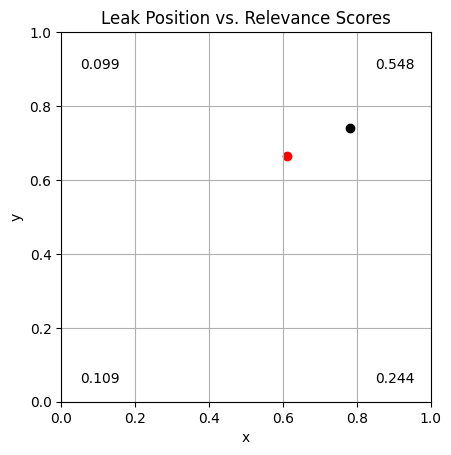

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

1.0
1.0
0.99999976
1.0
1.0
0.9999998
0.9999999
0.99999994
1.0000001
1.0
1.0
1.0



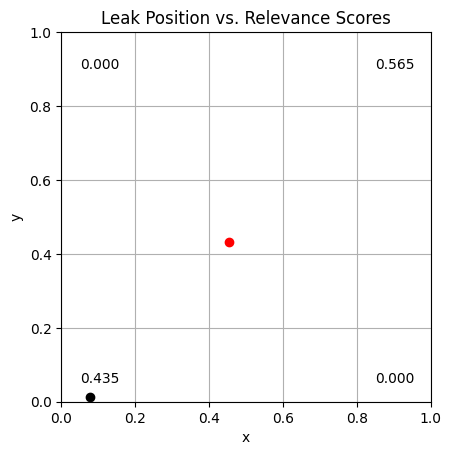

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

1.0000001
1.0000001
0.99999994
1.0
1.0
1.0
0.99999994
1.0
0.99999994
1.0000001
0.99999994
1.0



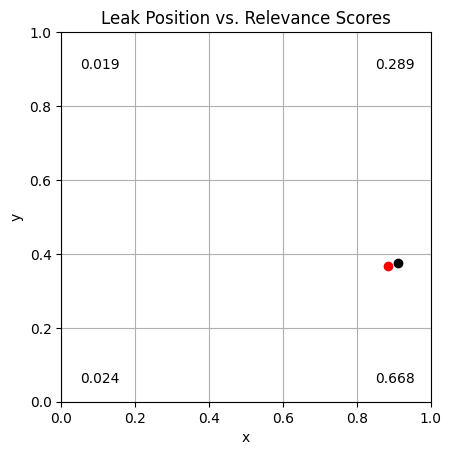

In [34]:
for i in range(3):

    x = X_test.values[i:i + 1, :]
    y = Y_test.values[i:i + 1, :]
    y_pred = model_wins.predict(x)   # <-- use your winning model
    scores, A = lrp(1, 0, model_wins, x)

    print()
    for score in scores:
        print(np.sum(score))
    print()

    plt.figure()
    plt.scatter(y[0, 0], y[0, 1], c='k')   # ground truth
    plt.scatter(y_pred[0, 0], y_pred[0, 1], c='r')  # prediction
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel('x')
    plt.ylabel('y')

    # The four relevance scores for the MFC inputs
    plt.text(0.05, 0.9,  f'{scores[0][0, 0].numpy():.3f}')
    plt.text(0.85, 0.9,  f'{scores[0][0, 1].numpy():.3f}')
    plt.text(0.85, 0.05, f'{scores[0][0, 2].numpy():.3f}')
    plt.text(0.05, 0.05, f'{scores[0][0, 3].numpy():.3f}')

    plt.title('Leak Position vs. Relevance Scores')
    plt.show()

**Checkpoint:** If your LRP implementation is correct, then the layerwise aggregated sums of relevance scores should be very close to one throughout.